## Lloyds Banking Group

## Import The Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## STEP 1: Identify & Gather Data

In [2]:
import pandas as pd

xls = pd.ExcelFile('Customer_Churn_Data_Large.xlsx')
print(xls.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [3]:
cust = pd.read_excel('Customer_Churn_Data_Large.xlsx', 
                     sheet_name='Customer_Demographics')

cust.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [4]:
tran = pd.read_excel('Customer_Churn_Data_Large.xlsx', 
                     sheet_name='Transaction_History')
tran.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [5]:
service = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name = 'Customer_Service')
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [6]:
activity = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name = 'Online_Activity')
activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [7]:
churn = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name = 'Churn_Status')
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [8]:
cust_tran = pd.merge(cust,tran,how = 'inner',on = 'CustomerID')

In [9]:
cust_tran_serv = pd.merge(cust_tran,service,how = 'inner',on = 'CustomerID')

In [10]:
cust_tran_serv_act = pd.merge(cust_tran_serv,activity,how = 'inner',on = 'CustomerID')

In [11]:
df = pd.merge(cust_tran_serv_act,churn,how = 'inner',on='CustomerID')
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


## STEP 2: Perform EDA (Exploratory Data Analysis)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   object        
 3   MaritalStatus     5204 non-null   object        
 4   IncomeLevel       5204 non-null   object        
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   object        
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [13]:
df.describe()

,CustomerID,Age,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204,5204.000000,5204.000000,5204,5204,5204.000000,5204.000000
mean,496.470407,43.140085,5495.988470,2022-06-29 08:30:15.219062272,254.354940,5921.861261,2022-07-01 16:31:10.561106944,2023-07-04 09:27:31.960030720,25.918332,0.205995
min,1.000000,18.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,0.000000
25%,244.000000,29.000000,3218.000000,2022-03-30 00:00:00,128.940000,3873.250000,2022-04-07 00:00:00,2023-04-04 00:00:00,14.000000,0.000000
50%,504.000000,43.000000,5490.000000,2022-06-27 00:00:00,255.175000,5903.000000,2022-07-02 00:00:00,2023-07-11 00:00:00,27.000000,0.000000
75%,743.000000,57.000000,7713.000000,2022-09-28 00:00:00,378.605000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,0.000000
max,995.000000,69.000000,9997.000000,2022-12-31 00:00:00,499.700000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,1.000000
std,286.681289,15.430343,2595.575295,NaN,143.329654,2332.331260,NaN,NaN,14.110627,0.404466


In [14]:
df.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   object        
 3   MaritalStatus     5204 non-null   object        
 4   IncomeLevel       5204 non-null   object        
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   object        
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [16]:
df['day_since_last_login'] = (pd.to_datetime('today')  - df['LastLoginDate']).dt.days

In [17]:
# Transaction_Month
df['TransactionMonth'] = df['TransactionDate'].dt.month

In [18]:
# Interaction count per customer
interaction_count = df.groupby('CustomerID')['InteractionID'].count().reset_index(name='TotalInteraction')
df   = df.merge(interaction_count,on = 'CustomerID',how='left')

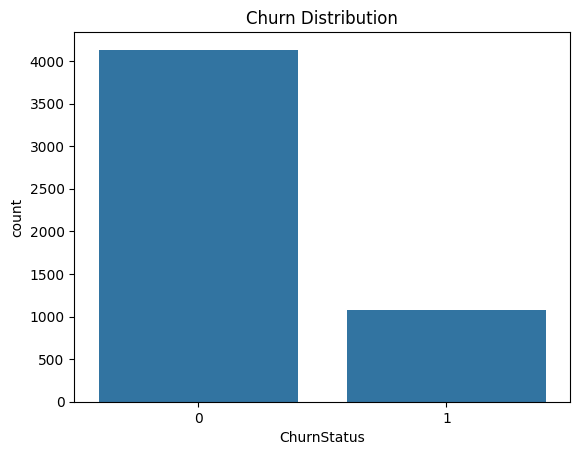

In [19]:
# churn Distribution
sns.countplot(x = 'ChurnStatus',data = df)
plt.title('Churn Distribution')
plt.show()

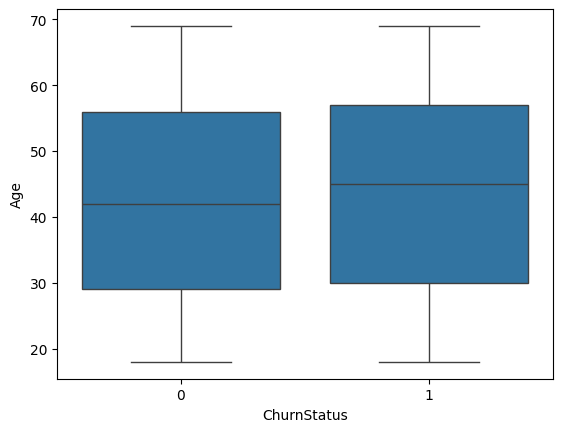

In [20]:
# Age vs churn
sns.boxplot(x='ChurnStatus',y='Age',data =df)
plt.show()

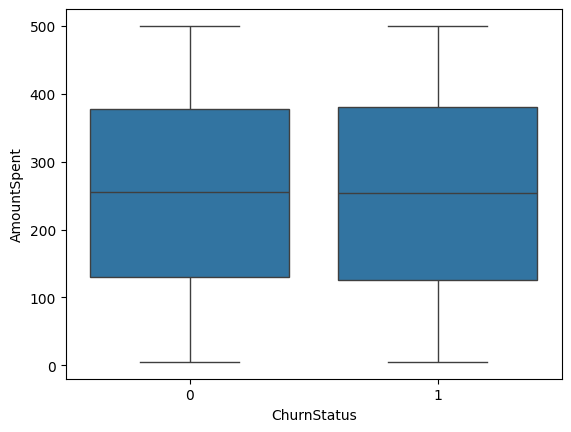

In [21]:
# Amount Spend vs churn
sns.boxplot(x='ChurnStatus', y='AmountSpent'	, data=df)
plt.show()

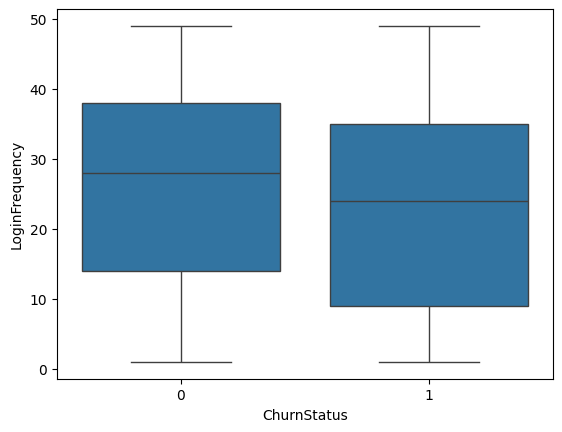

In [22]:
# Login Frequency vs Churn
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=df)
plt.show()

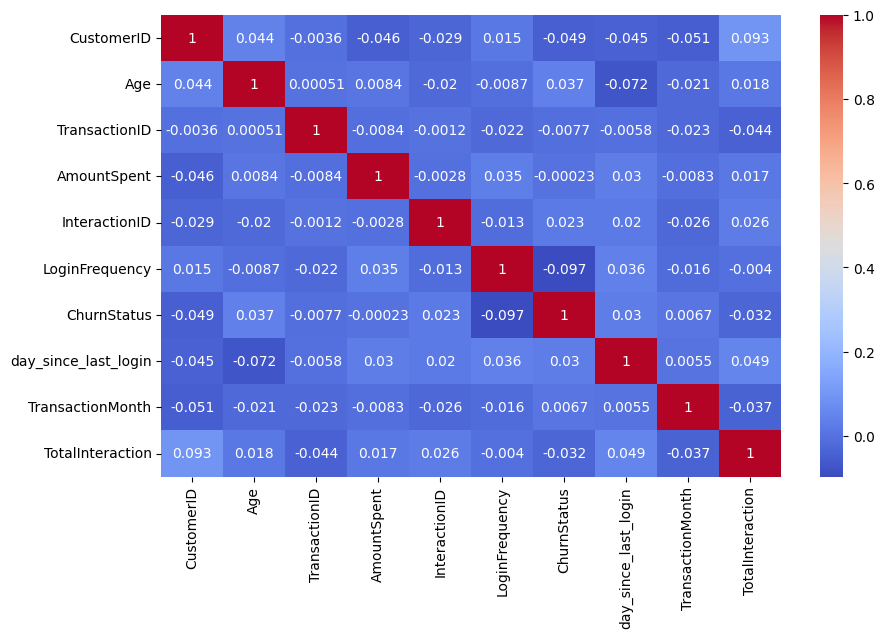

In [23]:
## Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Data cleaning

In [24]:
## Drop unnecessary columns
df.drop(['CustomerID', 'TransactionID', 'InteractionID'], axis=1, inplace=True)

In [25]:
# Handle outliers
for col in ['Age', 'AmountSpent', 'LoginFrequency']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

# Encode the categorical Variable

In [26]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

In [27]:
cols = ['Gender','MaritalStatus','IncomeLevel',
        'InteractionType','ResolutionStatus','ServiceUsage','ProductCategory']

for col in cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [28]:
df

,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,day_since_last_login,TransactionMonth,TotalInteraction
0,62.0,1,2,1,2022-03-27,416.50,2,2022-03-31,2,0,2023-10-21,34.0,0,0,880,3,1
1,65.0,1,1,1,2022-08-08,54.96,1,2022-03-17,2,0,2023-12-05,5.0,2,1,835,8,7
2,65.0,1,1,1,2022-07-25,197.50,2,2022-03-17,2,0,2023-12-05,5.0,2,1,835,7,7
3,65.0,1,1,1,2022-01-25,101.31,3,2022-03-17,2,0,2023-12-05,5.0,2,1,835,1,7
4,65.0,1,1,1,2022-07-24,397.37,1,2022-03-17,2,0,2023-12-05,5.0,2,1,835,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5199,23.0,0,0,1,2022-03-19,225.82,3,2022-05-02,2,0,2023-07-31,34.0,2,1,962,3,5
5200,23.0,0,0,1,2022-08-30,494.90,4,2022-05-02,2,0,2023-07-31,34.0,2,1,962,8,5
5201,23.0,0,0,1,2022-10-23,101.21,1,2022-05-02,2,0,2023-07-31,34.0,2,1,962,10,5
5202,23.0,0,0,1,2022-10-18,73.91,1,2022-05-02,2,0,2023-07-31,34.0,2,1,962,10,5


## Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Age', 'AmountSpent', 'LoginFrequency', 'day_since_last_login', 'TotalInteraction']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [30]:
## Final Dataset 
print(df.head())
print(df.shape)

        Age  Gender  MaritalStatus  IncomeLevel TransactionDate  AmountSpent  \
0  1.222379       1              2            1      2022-03-27     1.131382   
1  1.416820       1              1            1      2022-08-08    -1.391297   
2  1.416820       1              1            1      2022-07-25    -0.396711   
3  1.416820       1              1            1      2022-01-25    -1.067885   
4  1.416820       1              1            1      2022-07-24     0.997901   

   ProductCategory InteractionDate  InteractionType  ResolutionStatus  \
0                2      2022-03-31                2                 0   
1                1      2022-03-17                2                 0   
2                2      2022-03-17                2                 0   
3                3      2022-03-17                2                 0   
4                1      2022-03-17                2                 0   

  LastLoginDate  LoginFrequency  ServiceUsage  ChurnStatus  \
0    2023-10-21   

In [31]:
## Import the Machine Learning Libraries
# Model & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Define Features & Target

In [32]:
date_cols = ['TransactionDate', 'InteractionDate', 'LastLoginDate']
df.drop(date_cols,axis=1,inplace=True)

In [35]:
X = df.drop("ChurnStatus", axis=1)  
y = df["ChurnStatus"]

## Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training (Random Forest)

In [37]:
model = RandomForestClassifier(class_weight='balanced',random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,-1]

In [39]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[827   0]
 [  9 205]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       827
           1       1.00      0.96      0.98       214

    accuracy                           0.99      1041
   macro avg       0.99      0.98      0.99      1041
weighted avg       0.99      0.99      0.99      1041


ROC-AUC Score: 0.9989546723321543


## 10. Hyperparameter Tuning

In [40]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


## Feature Importance

In [41]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

day_since_last_login    0.190308
LoginFrequency          0.173713
Age                     0.147340
TotalInteraction        0.127671
MaritalStatus           0.070048
IncomeLevel             0.056165
AmountSpent             0.055585
ServiceUsage            0.048683
InteractionType         0.033001
TransactionMonth        0.031389
dtype: float64


In [ ]:
“I performed feature engineering on date columns, encoded categorical variables, and trained a Random Forest model with class balancing. I optimized it using GridSearchCV and evaluated it using recall, F1-score, and ROC-AUC. Finally, I extracted feature importance to provide business-driven churn insights.”